# Imports

In [9]:
import torch
from torch.nn import CrossEntropyLoss
from segmentation_models_pytorch.losses import DiceLoss
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import list_models, ResNet18_Weights

from RuralDataset import RuralDataset
from SegmentationModel import SegmentationModel
from Trainer import Trainer
from Evaluator import Evaluator
from DeepLabV3_ResNet50 import DeepLabV3_ResNet50

torch.cuda.empty_cache()

# Configuration parameters

In [10]:
DATA_ROOT = 'train'
BATCH_SIZE = 16
LEARNING_RATE = 0.0001
NUM_EPOCHS = 20
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'

# Device configuration

In [11]:
if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


# Transforms initialization

In [12]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Define Albumentations transformations
train_albumentations_transform = A.Compose([
    A.RandomResizedCrop(size=(512, 512), scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.Affine(translate_percent=(0.05, 0.05), scale=(0.95, 1.05), shear=5, p=0.5),
    A.Perspective(scale=(0.01, 0.1), p=0.3),
    A.GaussianBlur(blur_limit=5, sigma_limit=(0.1, 2.0), p=0.5),
    A.Resize(height=512, width=512), # Fixed resize
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

val_albumentations_transform = A.Compose([
    A.Resize(height=512, width=512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

# Dataset loading and splitting into training and validation sets

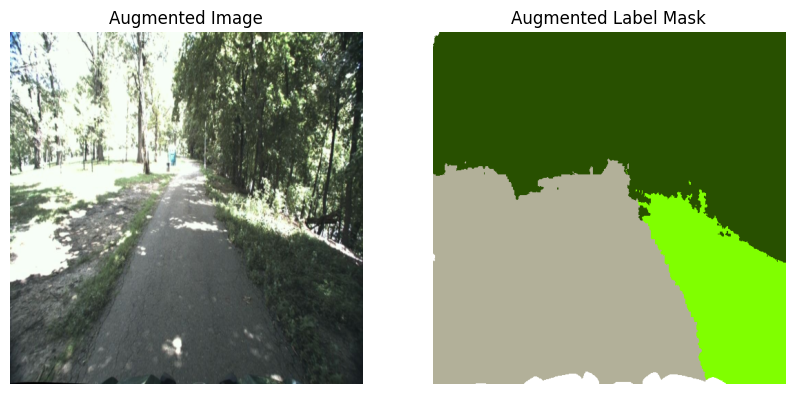

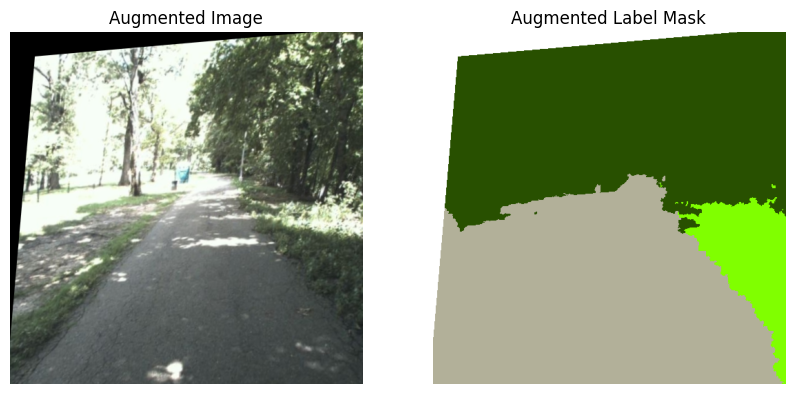

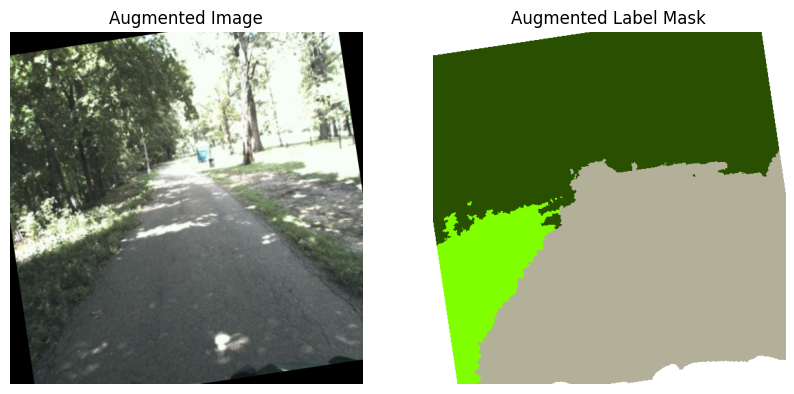

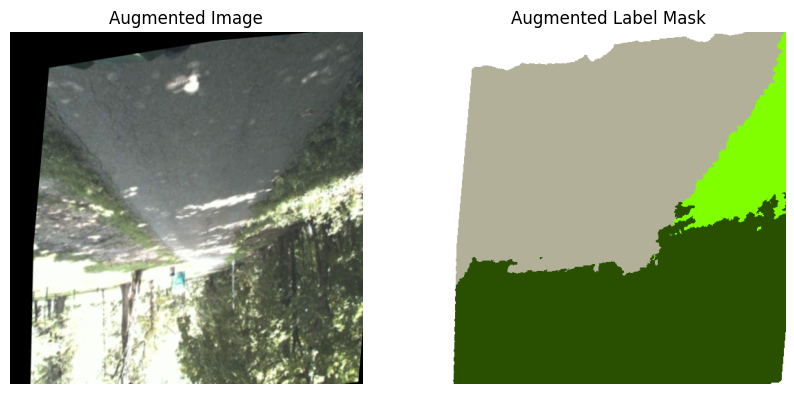

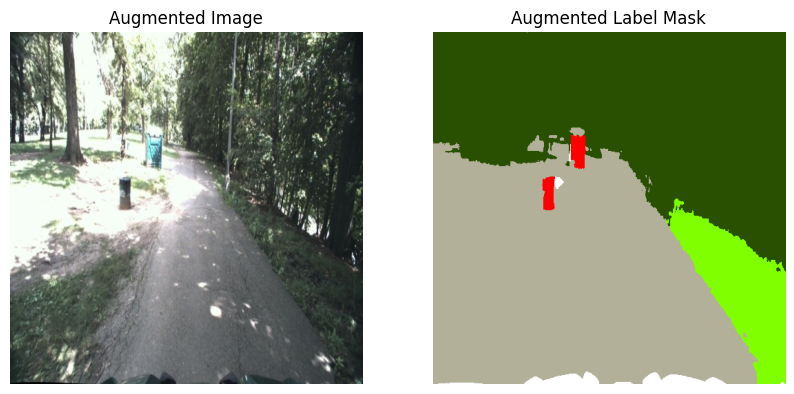

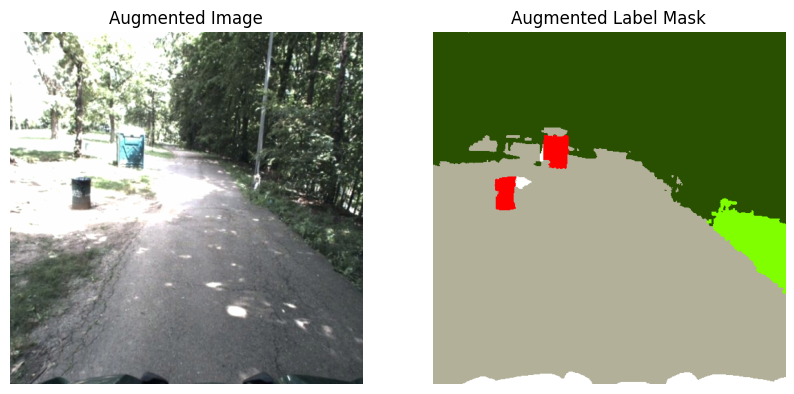

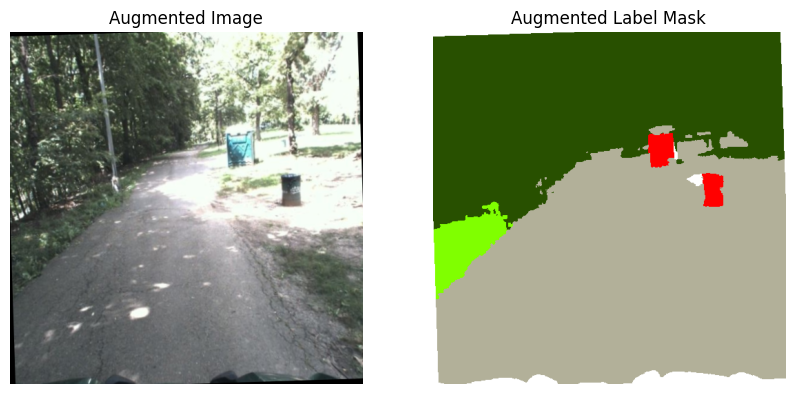

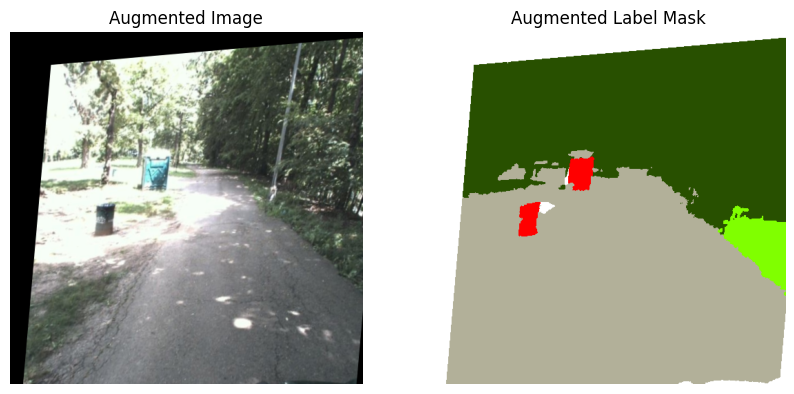

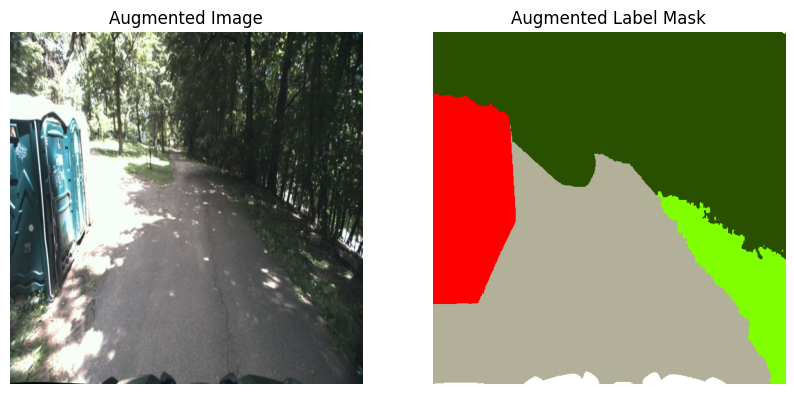

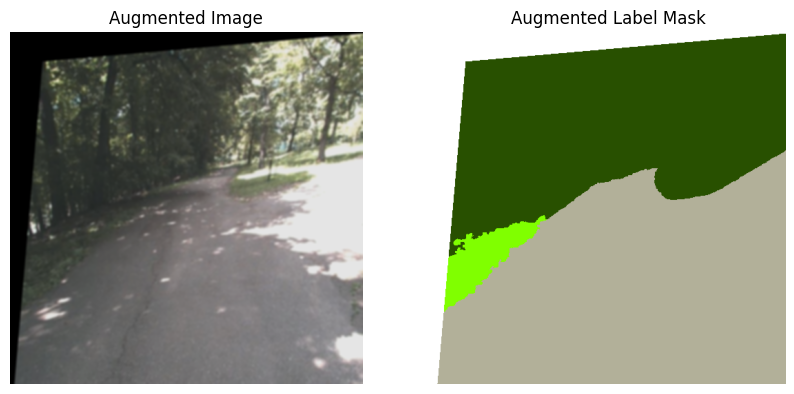

Training on 3724 samples, validating on 187 samples.


In [13]:
from logging import root
# Crea dataset separati con le rispettive trasformazioni
from torch.utils.data import random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
import torch # Import torch

from LabelMapper import LabelMapper

# Crea il dataset originale senza augmentation per ottenere gli indici di split
original_dataset = RuralDataset(root_dir=DATA_ROOT)

# Suddividi gli indici del dataset originale in train e val
train_size = int(0.8 * len(original_dataset))
val_size = len(original_dataset) - train_size

train_dataset_indices, val_dataset_indices = random_split(original_dataset, [train_size, val_size])

# Ora crea i dataset effettivi applicando augmentation e trasformazioni
# Crea il dataset di training con augmentation e la trasformazione di training, usando gli indici di training
train_dataset_augmented = RuralDataset(root_dir=DATA_ROOT, transform=train_albumentations_transform, augment=True)

# Crea il dataset di validazione senza augmentation e con la trasformazione di validazione, usando gli indici di validazione
val_dataset = RuralDataset(root_dir=DATA_ROOT, transform=val_albumentations_transform, augment=False)
val_subset = Subset(val_dataset, val_dataset_indices.indices)

# Visualizza un esempio di immagine e label dal dataset aumentato
count = 0
for images, labels in train_dataset_augmented:
    if count >= 10:
        break
    # Assuming images is a tensor of shape (C, H, W) and labels is a tensor of shape (H, W)
    # Convert image tensor back to numpy for visualization
    image_np = images.permute(1, 2, 0).numpy()
    # Denormalize for visualization (using ImageNet stats)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_np = std * image_np + mean
    image_np = np.clip(image_np, 0, 1) # Clip values to be within [0, 1]

    # Convert label tensor to numpy
    label_np = labels.numpy()

    # Map class IDs to colors for visualization
    label_mapper = LabelMapper()
    label_rgb = np.zeros((label_np.shape[0], label_np.shape[1], 3), dtype=np.uint8)
    for r in range(label_np.shape[0]):
        for c in range(label_np.shape[1]):
            class_id = label_np[r, c]
            color = label_mapper.class_id_to_color.get(class_id, (0, 0, 0)) # Default to black if not found
            label_rgb[r, c] = color

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Augmented Image")
    plt.imshow(image_np)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Augmented Label Mask")
    plt.imshow(label_rgb)
    plt.axis('off')

    plt.show()
    count += 1


train_loader = DataLoader(
    train_dataset_augmented, batch_size=BATCH_SIZE, num_workers=16, shuffle=True,
    pin_memory=True)
val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE, num_workers=16, shuffle=False,
    pin_memory=True)

print(f"Training on {len(train_loader.dataset)} samples, validating on {len(val_loader.dataset)} samples.")

# Model initialization

In [14]:
# model = SegmentationModel(NUM_CLASSES)
from torchvision.models.segmentation import *

# model = DeepLabV3_ResNet50(n_class=NUM_CLASSES)
model = lraspp_mobilenet_v3_large(num_classes=NUM_CLASSES)


model.to(device)
print("Model architecture:")
print(model)

Model architecture:
LRASPP(
  (backbone): IntermediateLayerGetter(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_si

# Loss Function and optimizer definition

In [15]:
# weights = Trainer.compute_class_weights(train_loader, num_classes=NUM_CLASSES)
weights = [ 3.8668,  1.0843,  0.7316,  0.7333,  0.8368,  0.3093,  1.7578, 62.0476, 13.2180]

cross_entropy = CrossEntropyLoss(weight=torch.tensor(weights).to(device))
dice_loss = DiceLoss(mode='multiclass')

def combined_loss(pred, target):
    return cross_entropy(pred, target) + dice_loss(pred, target)

criterion = combined_loss
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


# Trainer initialization and training

In [ ]:
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")


Starting training...

Epoch 1/20
Batch 1/233, Loss: 3.1845
Batch 2/233, Loss: 2.9656
Batch 3/233, Loss: 2.9520
Batch 4/233, Loss: 3.1269
Batch 5/233, Loss: 2.8368
Batch 6/233, Loss: 2.8644
Batch 7/233, Loss: 2.9632
Batch 8/233, Loss: 2.7494
Batch 9/233, Loss: 2.9562
Batch 10/233, Loss: 2.7273
Batch 11/233, Loss: 2.6442
Batch 12/233, Loss: 2.6378
Batch 13/233, Loss: 2.6795
Batch 14/233, Loss: 2.5108
Batch 15/233, Loss: 2.6246
Batch 16/233, Loss: 2.4436
Batch 17/233, Loss: 2.5844
Batch 18/233, Loss: 2.4935
Batch 19/233, Loss: 2.1393
Batch 20/233, Loss: 2.7136
Batch 21/233, Loss: 2.3674
Batch 22/233, Loss: 2.2921
Batch 23/233, Loss: 2.2117
Batch 24/233, Loss: 2.3908
Batch 25/233, Loss: 2.7021
Batch 26/233, Loss: 2.3147
Batch 27/233, Loss: 2.1952
Batch 28/233, Loss: 2.0898
Batch 29/233, Loss: 2.0192
Batch 30/233, Loss: 2.1619
Batch 31/233, Loss: 2.2101
Batch 32/233, Loss: 2.1130
Batch 33/233, Loss: 2.0199
Batch 34/233, Loss: 2.3287
Batch 35/233, Loss: 2.1525
Batch 36/233, Loss: 2.0860
Bat

# Model evaluation

In [10]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

evaluator = Evaluator(model, val_loader, device)
metrics = evaluator.evaluate_classification_metrics()

TypeError: argmax(): argument 'input' (position 1) must be Tensor, not collections.OrderedDict

# Example Predict

In [17]:
evaluator.predict_from_folder(folder_number = 6, data_root = 'test')

Immagini non trovate in test\0007


In [10]:
print(metrics.get('accuracy', 'N/A'))
print(metrics.get('f1_score', 'N/A'))
print(metrics.get('precision', 'N/A'))
print(metrics.get('recall', 'N/A'))

0.9785395331561246
N/A
0.9528814661495557
0.9808973257994301
